In [24]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
sns.set(style='ticks')

import matplotlib.gridspec as gridspec
import ast
import sys
sys.path.append('../no_degeneracy/')
sys.path.append('../no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

#Colors
#----------------------------------------------
colors_june={'0.5x':['#fee0d2', '#deebf7'],
       '1x':['#fc9272', '#9ecae1'],
       '2x':['#de2d26', '#3182bd'] }

color_noise=sns.color_palette("colorblind")[5]
color_data='#636363'
color_bms=colors_june['2x'][1]
color_ann=colors_june['2x'][0]
#-----------------------------------------------

In [25]:
#Read NN and BMS data
function='leaky_ReLU' #tanh, leaky_ReLU
n=0;sigma=0.0;realization=2

runid=0;
NPAR=10 #10, 20
steps=50000

resolution='1x' #'0.5x', '1x', '2x', '4e-3'
resolutions={'0.5x':'0.1', '1x':'0.05' , '2x': '0.025' , '4e-3x':'0.004' }

#file_model='NN_no_overfit_' + function + '_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
#model_d='../../data/nns/' + resolution + '_resolution/approximation/' + file_model
#xlim=[-2,2]

#Read NN data
mode='out_of_rank'

if mode=='out_of_rank':
    input_path='../../data/nns/' + resolution + '_resolution/out_of_rank/'
    model_d=input_path + 'NN_out_of_rank_%s_sigma_%s_r_%d_res_%s.csv' %(function, str(sigma), realization, resolutions[resolution]) 
    xlim=[-2,14]

elif mode=='approximation':
    file_model='NN_no_overfit_' + function + '_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
    model_d='../../data/nns/' + resolution + '_resolution/approximation/' + file_model
    xlim=[-2,2]
    
    



d=pd.read_csv(model_d)
dn=d[d['rep']==n]
dn.set_index('Unnamed: 0', inplace=True)
dn.index.name = None
dn=dn.reset_index(drop=True)
display(dn)

#Read BMS trace
filename='BMS_'+function+'_n_'+str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_res_' + resolutions[resolution] + '_trace_'+\
                str(steps)+'_prior_'+str(NPAR)+ '.csv'

trace=pd.read_csv('../../data/MSTraces/' + resolution + '_resolution/' + filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])

,x1,y,rep,ymodel
0,-2.00,0.001005,0.0,-0.012558
1,-1.95,0.001006,0.0,-0.012338
2,-1.90,0.001007,0.0,-0.011898
3,-1.85,0.001008,0.0,-0.011230
4,-1.80,0.001008,0.0,-0.010323
...,...,...,...,...
315,13.75,0.985643,0.0,0.214002
316,13.80,0.989232,0.0,0.213801
317,13.85,0.992822,0.0,0.213606
318,13.90,0.996411,0.0,0.213416


In [26]:
#Parameters to read models
VARS = ['x1',]
x = dn[[c for c in VARS]].copy()


if NPAR==10:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')
elif NPAR==20:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np20.maxs200.2024-05-10 162907.551306.dat')

In [27]:
#Minimum description length model
#y=dn.y_noise
y=dn.y

minrow = trace[trace.H == min(trace.H)].iloc[0]
minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)

t = Tree(
    variables=list(x.columns),
    parameters=['a%d' % i for i in range(NPAR)],
    x=x, y=y,
    prior_par=prior_par,
    max_size=200,
    from_string=minexpr,
)

t.set_par_values(deepcopy(minparvals))

<lambdifygenerated-189>:2: RuntimeWarning: overflow encountered in exp
  return _a6_**2*x1**2/(_a0_ + exp(_a7_*x1))**2
<lambdifygenerated-189>:2: RuntimeWarning: overflow encountered in square
  return _a6_**2*x1**2/(_a0_ + exp(_a7_*x1))**2
/export/home/shared/Projects/ANN/Sergio/BMS_approximator/bin/ann_functions/../no_degeneracy/mcmc.py:654: OptimizeWarning: Covariance of the parameters could not be estimated
  res = curve_fit(
<lambdifygenerated-190>:2: RuntimeWarning: overflow encountered in exp
  return _a6_**2*x1**2/(_a0_ + exp(_a7_*x1))**2
<lambdifygenerated-190>:2: RuntimeWarning: overflow encountered in square
  return _a6_**2*x1**2/(_a0_ + exp(_a7_*x1))**2
<lambdifygenerated-191>:2: RuntimeWarning: overflow encountered in exp
  return 4*_a6_**2*x1**2/(_a0_ + exp(_a7_*x1))**2
<lambdifygenerated-191>:2: RuntimeWarning: overflow encountered in square
  return 4*_a6_**2*x1**2/(_a0_ + exp(_a7_*x1))**2
<lambdifygenerated-192>:2: RuntimeWarning: overflow encountered in exp
  return 

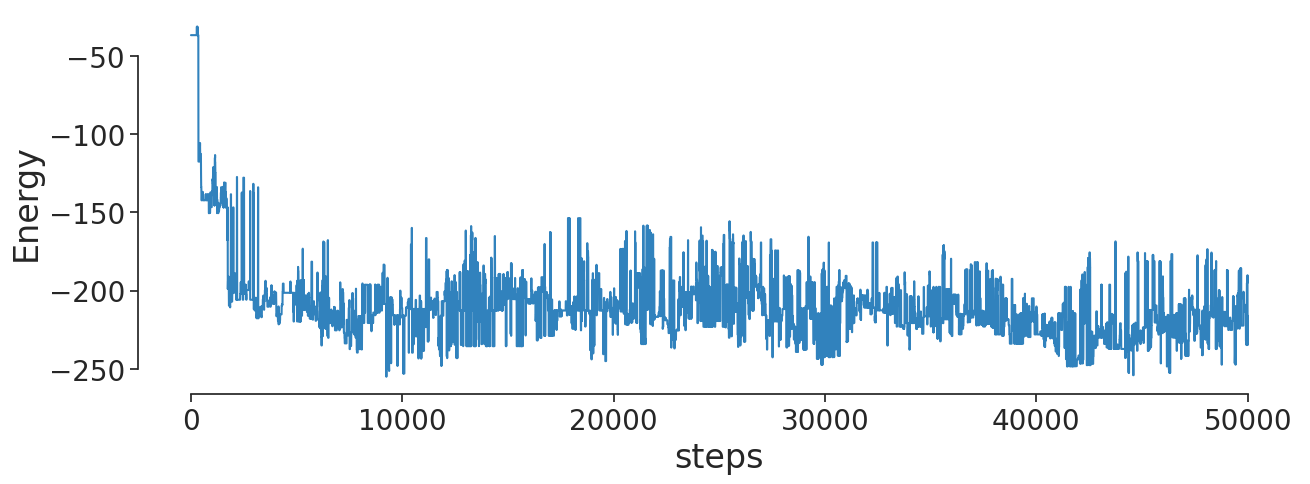

In [28]:
Nini = 00
plt.figure(figsize=(15, 5))




#Define figure size in cm                                                                           
Extensions=['.svg']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size                                                           
#plt.title(str(function) + ', ' + 'n=' + str(n) +', r=' + str(realization))
plt.plot(trace.t[trace.t > Nini], trace.H[trace.t > Nini], color=color_bms)
plt.xticks(fontsize=20);plt.yticks(fontsize=20)
plt.xlabel('steps',fontsize=24);plt.ylabel('Energy',fontsize=24)
#plt.scatter(minrow['t'], minH,color='r')
sns.despine(trim=True)

Name_figure='Energy_' + function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

for ext in Extensions:
        plt.savefig('../../results/' + Name_figure + ext,dpi=300)

 
plt.show()

320
9.95000000000001


,x1,y,rep,ymodel,ybms
199,7.95,0.569291,0.0,0.304905,14.851901
200,8.00,0.572880,0.0,0.303289,15.254284
201,8.05,0.576469,0.0,0.301692,15.667569
202,8.10,0.580059,0.0,0.300113,16.092051
203,8.15,0.583648,0.0,0.298551,16.528034
...,...,...,...,...,...
315,13.75,0.985643,0.0,0.214002,330.002932
316,13.80,0.989232,0.0,0.213801,338.943718
317,13.85,0.992822,0.0,0.213606,348.126738
318,13.90,0.996411,0.0,0.213416,357.558553


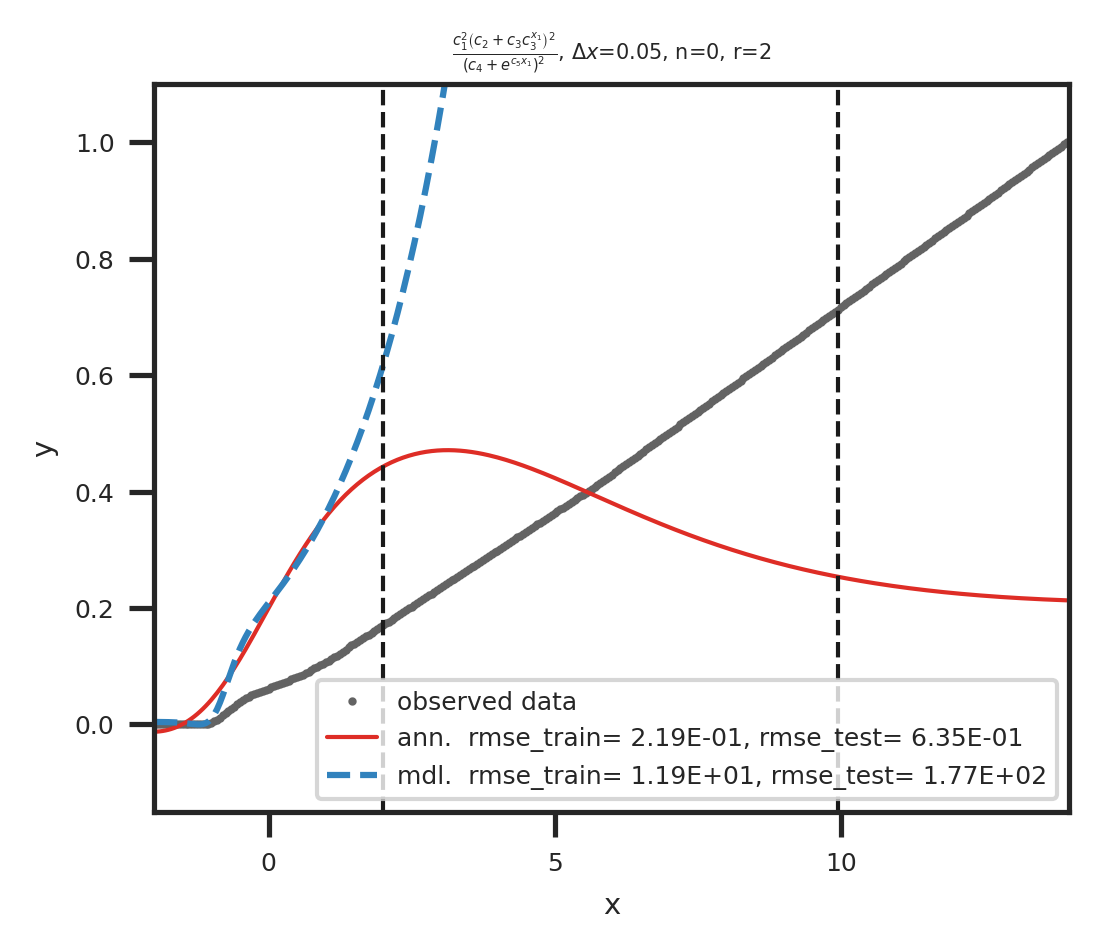

In [30]:
#Plot

#Validation and train borders
n_points=int(len(dn.index))
print(n_points)
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)


train_border=dn.loc[train_size_bms-1]['x1']
print(train_border)

dplot = deepcopy(dn)
dplot['ybms'] = t.predict(x)
display(dplot.loc[train_size_ann-1:])

#ann errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ymodel'],dplot.loc[:train_size_bms -1]['y'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size_bms-1:]['ymodel'],dplot.loc[train_size_bms -1:]['y'])
#rmse_nn_validation=root_mean_squared_error(dplot.iloc[validation_points]['ymodel'],dplot.iloc[validation_points]['y'])

#bms errors
rmse_mdl=root_mean_squared_error(dplot.ybms,dn.y)
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dn.loc[:train_size_bms-1]['y'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dn.loc[train_size_bms-1:]['y'])

 
#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 10*cm; height=8*cm

Extensions=['.png']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size                                                          


fig=figure(figsize=(width,height), dpi=300)           


 
                                                                            
#plt.plot(dn['x1'], dn['y_noise'],linewidth=line_w, markersize=2, color=color_noise,label=r'$\sigma$=' + str(sigma) )
plt.plot(dn['x1'], dn['y'],'.', markersize=2, color=color_data,label='observed data')     
plt.plot(dn['x1'], dn['ymodel'],linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_nn_train, rmse_nn_test))
plt.plot(dplot.x1, dplot.ybms, color=color_bms, linestyle='--',label='mdl.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_mdl_train, rmse_mdl_test))
plt.axvline(x=2,linestyle='--',linewidth=line_w, color='k')

#plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')

#plt.title('$%s$' % t.latex(),fontsize=size_title)
plt.title('$%s$, $\Delta x$=%s, n=%d, r=%d' % ( t.latex(),resolutions[resolution], n, realization),fontsize=size_title)
plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.legend(loc='best', fontsize=size_ticks)

plt.xlim(-2,xlim[1]);plt.ylim(-0.15,1.1)  


Name_figure='Prediction_' + resolution + '_' + function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

    
for ext in Extensions:
        plt.savefig('../../results/' + Name_figure +ext,dpi=300)

plt.show()